In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.5/913.5 kB 17.3 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from pathlib import Path


Configuración de acceso a Roboflow


In [ ]:
rf = Roboflow(api_key="8m6bzS5ZOJmJIPj9JDS1")
project = rf.workspace("coellocoronel").project("vehiculos-hkrqk")
version = project.version(6)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vehiculos-6 in yolov8:: 100%|██████████| 3410/3410 [00:00<00:00, 3746.66it/s]


In [ ]:
# Instanciar el modelo YOLOv8
model = YOLO("yolov8n.pt")

# Usar el archivo de configuración en lugar de una ruta de carpeta
results = model.train(
    data="/content/Vehiculos-6/data.yaml",  # Ruta al archivo .yaml que acabas de crear
    epochs=20,
    batch=16,
    imgsz=640,
    patience=20,
    verbose=True
)

# Guardar el modelo entrenado
model.save(f"modelo_entrenado.pt")


100%|██████████| 6.25M/6.25M [00:00<00:00, 73.4MB/s]


Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Vehiculos-6/data.yaml, epochs=20, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes

100%|██████████| 755k/755k [00:00<00:00, 13.9MB/s]


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/Vehiculos-6/train/labels... 1398 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1398/1398 [00:01<00:00, 1135.40it/s]

...

      20/20         0G     0.6529     0.5393     0.8875         25        640: 100%|██████████| 88/88 [20:27<00:00, 13.95s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:41<00:00,  5.89s/it]

                   all        201       1017      0.772      0.706       0.78      0.603



20 epochs completed in 7.129 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:35<00:00,  5.12s/it]


                   all        201       1017      0.773      0.704       0.78      0.603
             automovil        192        719      0.837      0.826      0.888      0.716
                   bus         35         47      0.743      0.799      0.818      0.613
                camion         51         58       0.86      0.739      0.843       0.65
             camioneta         54         62      0.708      0.565      0.703      0.575
             furgoneta         45         51      0.716      0.647      0.713      0.611
                  moto         66         80      0.774       0.65      0.713      0.455
Speed: 2.0ms preprocess, 162.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/train


Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/Vehiculos-6/valid/labels.cache... 201 images, 0 backgrounds, 0 corrupt: 100%|██████████| 201/201 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:35<00:00,  2.71s/it]


                   all        201       1017      0.788      0.697      0.786      0.647
             automovil        192        719      0.845      0.826      0.886      0.753
                   bus         35         47      0.783       0.77      0.844      0.671
                camion         51         58      0.894      0.724      0.831      0.705
             camioneta         54         62       0.72      0.565        0.7      0.608
             furgoneta         45         51      0.698      0.647      0.713      0.633
                  moto         66         80      0.785       0.65      0.743      0.511
Speed: 1.9ms preprocess, 161.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs/detect/val
Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)


val: Scanning /content/Vehiculos-6/valid/labels.cache... 201 images, 0 backgrounds, 0 corrupt: 100%|██████████| 201/201 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:33<00:00,  2.61s/it]


                   all        201       1017      0.789      0.703      0.784       0.65
             automovil        192        719      0.845      0.828      0.869      0.747
                   bus         35         47      0.787      0.787      0.843      0.674
                camion         51         58      0.896      0.741      0.833      0.708
             camioneta         54         62      0.714      0.565      0.697       0.61
             furgoneta         45         51      0.702      0.647      0.711      0.637
                  moto         66         80      0.788       0.65      0.753      0.526
Speed: 1.8ms preprocess, 155.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val2
Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)


val: Scanning /content/Vehiculos-6/valid/labels.cache... 201 images, 0 backgrounds, 0 corrupt: 100%|██████████| 201/201 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:35<00:00,  2.76s/it]


                   all        201       1017      0.869      0.624      0.766      0.651
             automovil        192        719      0.901      0.747       0.84      0.734
                   bus         35         47       0.85      0.723      0.825      0.672
                camion         51         58      0.947      0.621      0.785      0.693
             camioneta         54         62      0.865      0.516      0.712      0.641
             furgoneta         45         51      0.778      0.549      0.692      0.629
                  moto         66         80       0.87      0.588      0.744      0.535
Speed: 1.8ms preprocess, 165.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val3

Resultados por umbral de confianza:
      precision    recall     mAP50       mAP
0.25   0.787533  0.696908  0.786102  0.646622
0.45   0.788755  0.702954  0.784371  0.650499
0.65   0.868565  0.623936  0.766213  0.650567


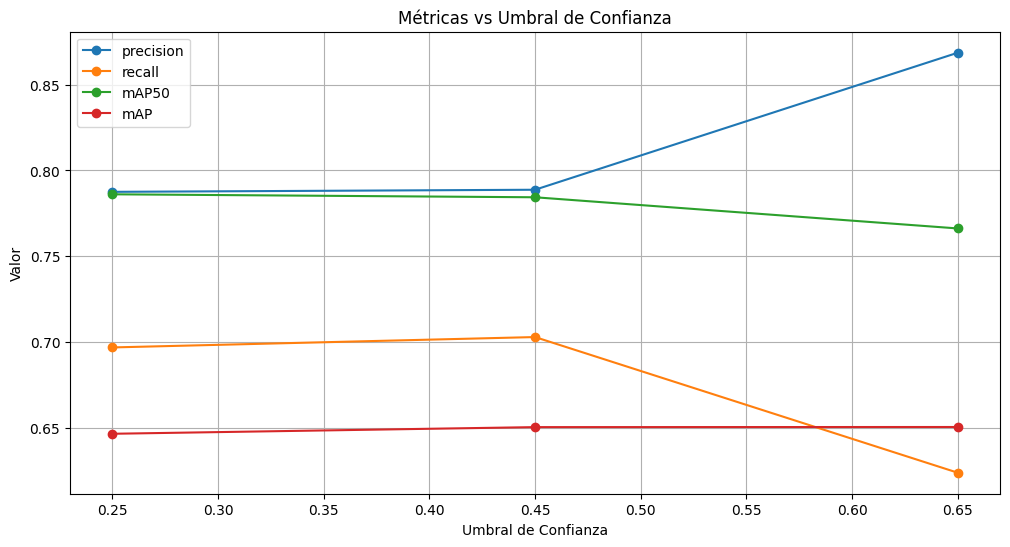

Ultralytics 8.3.58 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/Vehiculos-6/valid/labels.cache... 201 images, 0 backgrounds, 0 corrupt: 100%|██████████| 201/201 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:33<00:00,  2.57s/it]


                   all        201       1017      0.789      0.703      0.784       0.65
             automovil        192        719      0.845      0.828      0.869      0.747
                   bus         35         47      0.787      0.787      0.843      0.674
                camion         51         58      0.896      0.741      0.833      0.708
             camioneta         54         62      0.714      0.565      0.697       0.61
             furgoneta         45         51      0.702      0.647      0.711      0.637
                  moto         66         80      0.788       0.65      0.753      0.526
Speed: 1.7ms preprocess, 153.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val4

Resultados detallados con conf=0.45:
mAP50: 0.7844
mAP: 0.6505
Precisión Media: 0.7888
Recall Medio: 0.7030

Generando matriz de confusión...


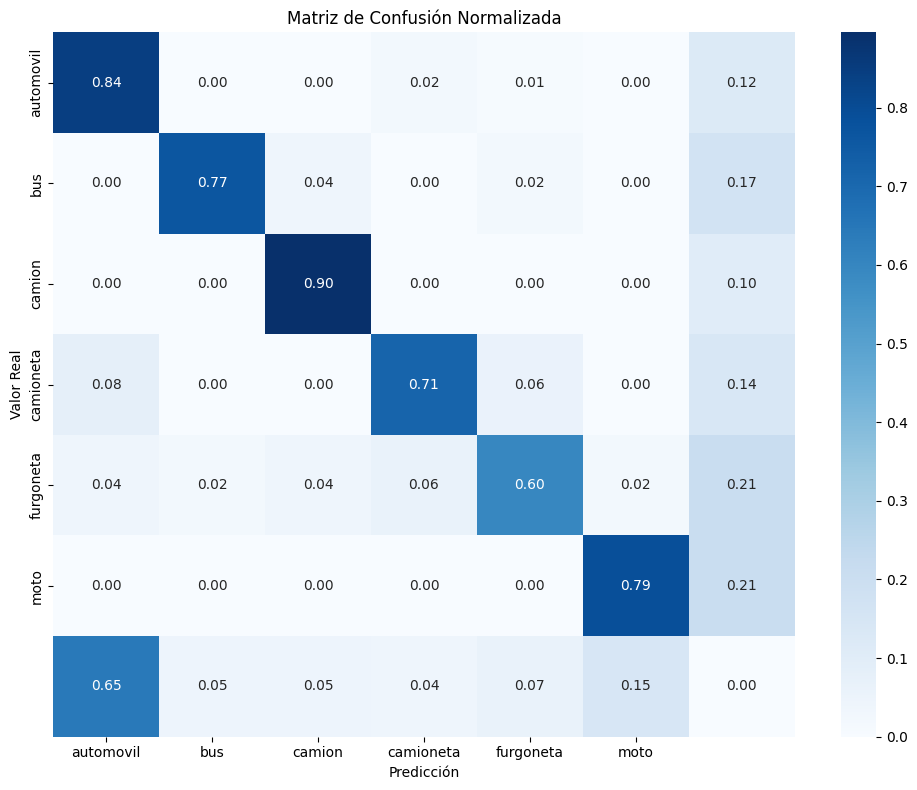


Métricas por clase:


<Figure size 1200x600 with 0 Axes>

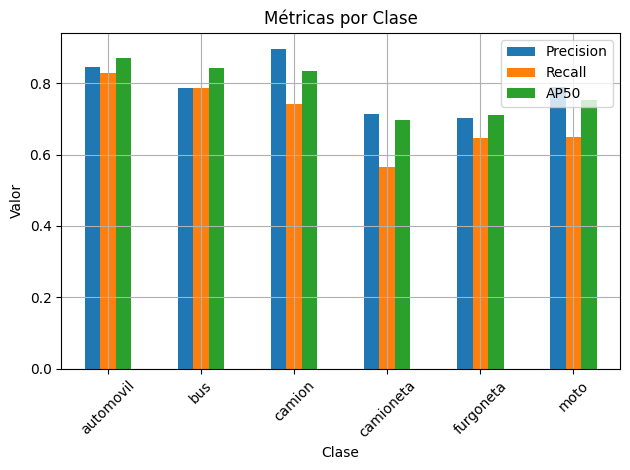

           Precision    Recall      AP50
automovil   0.845170  0.827538  0.868775
bus         0.787234  0.787234  0.843277
camion      0.895833  0.741379  0.833389
camioneta   0.714286  0.564516  0.696966
furgoneta   0.702128  0.647059  0.711079
moto        0.787879  0.650000  0.752740


In [ ]:
from ultralytics import YOLO
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import os

def evaluate_yolo_model(model_path, data_yaml, conf_thresholds=[0.25, 0.45, 0.65]):
    results = {}
    model = YOLO(model_path)

    for conf in conf_thresholds:
        metrics = model.val(data=data_yaml,
                          conf=conf,
                          iou=0.5)

        results[conf] = {
            'precision': float(metrics.box.mp),
            'recall': float(metrics.box.mr),
            'mAP50': float(metrics.box.map50),
            'mAP': float(metrics.box.map)
        }

    return results

def get_validation_data(data_yaml):
    """
    Obtiene la ruta del conjunto de validación desde el archivo data.yaml
    """
    with open(data_yaml, 'r') as f:
        data = yaml.safe_load(f)

    # Obtener el directorio base donde está el archivo data.yaml
    base_dir = os.path.dirname(os.path.abspath(data_yaml))

    # Convertir rutas relativas a absolutas
    val_path = os.path.join(base_dir, data['val'])
    if 'names' in data:
        class_names = data['names']
    else:
        class_names = [f"clase_{i}" for i in range(data['nc'])]

    return val_path, class_names

def plot_confusion_matrix(conf_matrix, class_names):
    """
    Visualiza la matriz de confusión
    """
    # Obtener los valores de la matriz como array
    matrix = conf_matrix.matrix

    # Convertir a numpy array si no lo es
    if not isinstance(matrix, np.ndarray):
        matrix = np.array(matrix)

    # Normalizar por filas
    with np.errstate(divide='ignore', invalid='ignore'):
        matrix_normalized = matrix / matrix.sum(axis=1, keepdims=True)
        matrix_normalized = np.nan_to_num(matrix_normalized)

    # Visualizar
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_normalized,
                annot=True,
                fmt='.2f',
                cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Matriz de Confusión Normalizada')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

    return matrix_normalized

def plot_metrics(results_df):
    plt.figure(figsize=(12, 6))
    for metric in results_df.columns:
        plt.plot(results_df.index, results_df[metric], marker='o', label=metric)
    plt.title('Métricas vs Umbral de Confianza')
    plt.xlabel('Umbral de Confianza')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_class_metrics(metrics, class_names):
    precisions = metrics.box.p
    recalls = metrics.box.r
    ap50s = metrics.box.ap50

    df = pd.DataFrame({
        'Precision': precisions,
        'Recall': recalls,
        'AP50': ap50s
    }, index=class_names)

    plt.figure(figsize=(12, 6))
    df.plot(kind='bar')
    plt.title('Métricas por Clase')
    plt.xlabel('Clase')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df

def analyze_model_performance(model_path, data_yaml):
    """
    Realiza un análisis completo del rendimiento del modelo
    """
    model = YOLO(model_path)

    # Obtener nombres de clases
    _, class_names = get_validation_data(data_yaml)

    # Evaluar con diferentes umbrales de confianza
    conf_thresholds = [0.25, 0.45, 0.65]
    results = evaluate_yolo_model(model_path, data_yaml, conf_thresholds)

    # Crear DataFrame con resultados
    df_results = pd.DataFrame(results).T
    print("\nResultados por umbral de confianza:")
    print(df_results)

    # Visualizar resultados generales
    plot_metrics(df_results)

    # Validación con configuración óptima y obtención de matriz de confusión
    metrics = model.val(data=data_yaml,
                       conf=0.45,
                       iou=0.5)

    # Imprimir resultados detallados
    print("\nResultados detallados con conf=0.45:")
    print(f"mAP50: {float(metrics.box.map50):.4f}")
    print(f"mAP: {float(metrics.box.map):.4f}")
    print(f"Precisión Media: {float(metrics.box.mp):.4f}")
    print(f"Recall Medio: {float(metrics.box.mr):.4f}")

    # Obtener y visualizar la matriz de confusión
    print("\nGenerando matriz de confusión...")
    confusion_matrix = metrics.confusion_matrix
    conf_matrix_norm = plot_confusion_matrix(confusion_matrix, class_names)

    # Analizar métricas por clase
    print("\nMétricas por clase:")
    class_metrics = plot_class_metrics(metrics, class_names)
    print(class_metrics)

    return metrics, df_results, conf_matrix_norm

# Ejemplo de uso
model_path = '/content/modelo_entrenado.pt'
data_yaml = '/content/Vehiculos-6/data.yaml'

metrics, results_df, conf_matrix = analyze_model_performance(model_path, data_yaml)